# Three-dimensional Disk Distribution Functions

The `quasiisothermaldf` class implements a quasi-isothermal distribution function
for three-dimensional disk populations. Unlike the 2D DFs, it is expressed in terms
of action-angle variables $(J_R, L_z, J_z)$ and requires an action-angle calculator.

In [1]:
%matplotlib inline
import numpy
import matplotlib.pyplot as plt

## Setup: potential and action-angle calculator

We use `MWPotential2014` as the gravitational potential and set up
an `actionAngleAdiabatic` instance to compute actions:

In [2]:
from galpy.potential import MWPotential2014
from galpy.actionAngle import actionAngleAdiabatic

aA = actionAngleAdiabatic(pot=MWPotential2014, c=True)

## Initializing the quasi-isothermal DF

The `quasiisothermaldf` takes radial scale lengths and velocity dispersions
as parameters:

- `hr`: radial scale length of the surface density
- `sr`: radial velocity dispersion at the solar radius
- `sz`: vertical velocity dispersion at the solar radius
- `hsr`: scale length of the radial velocity dispersion
- `hsz`: scale length of the vertical velocity dispersion

In [3]:
from galpy.df import quasiisothermaldf

qdf = quasiisothermaldf(
    hr=1.0 / 3.0,  # radial scale length
    sr=0.2,  # sigma_R at R_0
    sz=0.1,  # sigma_z at R_0
    hsr=1.0,  # sigma_R scale length
    hsz=1.0,  # sigma_z scale length
    pot=MWPotential2014,
    aA=aA,
)

## Evaluating the DF at a point

The DF can be evaluated at a given $(R, v_R, v_T, z, v_z)$ point.
Internally it computes the actions and evaluates $f(J_R, L_z, J_z)$:

In [4]:
# DF value at the solar circle moving on a circular orbit
print("f(R=1, vR=0, vT=1, z=0, vz=0) =", qdf(1.0, 0.0, 1.0, 0.0, 0.0))

f(R=1, vR=0, vT=1, z=0, vz=0) = [514.84583859]


## DF moments

The `quasiisothermaldf` can compute various moments by marginalizing
over velocity. These integrals use Gauss-Legendre quadrature by default.

In [5]:
# Vertically-integrated surface density at R=1
print("Surface mass at R=1:", qdf.surfacemass_z(1.0))

# Velocity dispersions at (R=1, z=0)
print("sigma_R^2 at (R=1, z=0):", qdf.sigmaR2(1.0, 0.0))
print("sigma_T^2 at (R=1, z=0):", qdf.sigmaT2(1.0, 0.0))
print("sigma_z^2 at (R=1, z=0):", qdf.sigmaR2(1.0, 0.0))

Surface mass at R=1: 0.5684828858456422
sigma_R^2 at (R=1, z=0): 0.04329359333259306
sigma_T^2 at (R=1, z=0): 0.023214249869379477
sigma_z^2 at (R=1, z=0): 0.04329359333259306


We can also compute the mean actions as a function of position:

In [6]:
print("<J_R> at (R=1, z=0):", qdf.meanjr(1.0, 0.0, mc=True, nmc=10000))
print("<L_z> at (R=1, z=0):", qdf.meanlz(1.0, 0.0, mc=True, nmc=10000))
print("<J_z> at (R=1, z=0):", qdf.meanjz(1.0, 0.0, mc=True, nmc=10000))

<J_R> at (R=1, z=0): 0.03476162847057026


<L_z> at (R=1, z=0): 0.9178279004379599


<J_z> at (R=1, z=0): 0.0017526441508768512


## Surface density profile

Let's compute and plot the surface density as a function of radius:

Text(0.5, 1.0, 'Quasi-isothermal DF surface density profile')

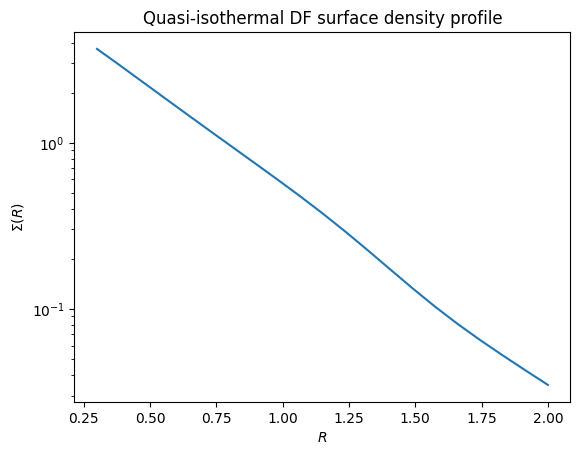

In [7]:
Rs = numpy.linspace(0.3, 2.0, 21)
smass = numpy.array([qdf.surfacemass_z(R) for R in Rs])
plt.semilogy(Rs, smass)
plt.xlabel(r"$R$")
plt.ylabel(r"$\Sigma(R)$")
plt.title("Quasi-isothermal DF surface density profile")

We can estimate the actual scale length from the DF by taking the log-slope:

In [8]:
# Estimate scale length from the DF near R=1
dR = 0.01
sm1 = qdf.surfacemass_z(1.0 - dR)
sm2 = qdf.surfacemass_z(1.0 + dR)
hR_est = -2.0 * dR / numpy.log(sm2 / sm1)
print(f"Estimated scale length: {hR_est:.3f} (input: {1.0 / 3.0:.3f})")

Estimated scale length: 0.372 (input: 0.333)


The actual scale length of the DF is close to, but not exactly equal to,
the input `hr` because the quasi-isothermal DF is only approximate.

## Velocity dispersion profiles

Text(0.5, 1.0, 'Velocity dispersion profiles')

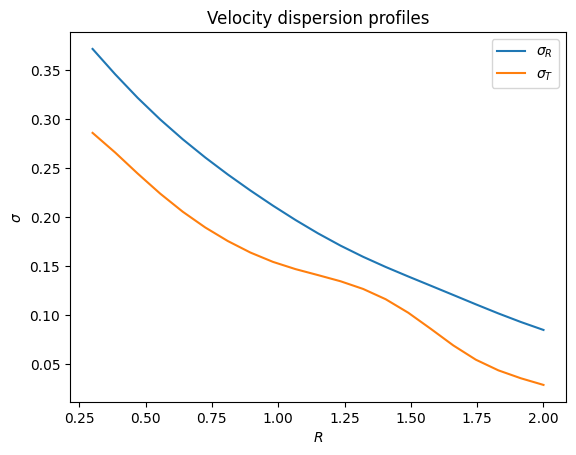

In [9]:
sigR2 = numpy.array([qdf.sigmaR2(R, 0.0) for R in Rs])
sigT2 = numpy.array([qdf.sigmaT2(R, 0.0) for R in Rs])
plt.plot(Rs, numpy.sqrt(sigR2), label=r"$\sigma_R$")
plt.plot(Rs, numpy.sqrt(sigT2), label=r"$\sigma_T$")
plt.xlabel(r"$R$")
plt.ylabel(r"$\sigma$")
plt.legend()
plt.title("Velocity dispersion profiles")